## Notebook to recreate a tissue sample from ambient maps

In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os
# import pickle
from PIL import Image
import torch 
# setting parameters:

width_cutoff = 1640 # um
pixel_per_um = 15.3846 # from BioRxiv paper

Script to write loom segmentation/celltype assignment data into the raw matrix:

In [49]:
# %pip install loompy
# Load osmFISH data
import loompy
import pickle
import numpy as np
from matplotlib.colors import to_rgba

width_cutoff = 1640 # um
pixel_per_um = 15.3846 # from BioRxiv paper


osmfish_loom = loompy.connect("/dh-projects/ag-ishaque/analysis/tiesmeys/data_home/zenodo/osmFISH/raw_data/osmFISH_SScortex_mouse_all_cells.loom")

osmfish_genes = list(osmfish_loom.row_attrs['Gene'])
osmfish_clusters = osmfish_loom.col_attrs['ClusterName']
osmfish_data = osmfish_loom[:,:].T[osmfish_clusters != "Excluded", :]
osmfish_clusters = osmfish_clusters[osmfish_clusters != "Excluded"]
osmfish_uniq_labels = sorted(set(osmfish_clusters) - set(['Excluded']))

with open("/dh-projects/ag-ishaque/analysis/tiesmeys/data_home/zenodo/osmFISH/raw_data/polyT_seg.pkl", "rb") as f:
    seg_dic = pickle.load(f)


osmfish_ref_colors = {
    "Inhibitory CP": "#9b067d",
    "Inhibitory Crhbp": "#9805cc",
    "Inhibitory Cnr1": "#ca4479",
    "Inhibitory IC": "#ff49b0",
    "Inhibitory Kcnip2": "#af7efe",
    "Inhibitory Pthlh": "#4e14a6",
    "Inhibitory Vip": "#7759a4",
    "Pyramidal Cpne5": "#3e4198",
    "Pyramidal L2-3": "#0ab4e4",
    "Pyramidal L2-3 L5": "#1e6a87",
    "Pyramidal Kcnip2": "#6787d6",
    "Pyramidal L3-4": "#004dba",
    "pyramidal L4": "#78edff",
    "Pyramidal L5": "#0a9fb4",
    "Pyramidal L6": "#027fd0",
    "Hippocampus": "#004b71",
    "Astrocyte Gfap": "#de4726",
    "Astrocyte Mfge8": "#f69149",
    "Oligodendrocyte Precursor cells": "#b3ee3d",
    "Oligodendrocyte COP": "#5dd73d",
    "Oligodendrocyte NF": "#64a44e",
    "Oligodendrocyte MF": "#2f7449",
    "Oligodendrocyte Mature": "#285528",
    "Perivascular Macrophages": "#762a14",
    "Microglia": "#a7623d",
    "C. Plexus": "#21b183",
    "Ependymal": "#fadf0b",
    "Pericytes": "#f8c495",
    "Endothelial": "#f81919",
    "Endothelial 1": "#f05556",
    "Vascular Smooth Muscle": "#aec470",
}
osmfish_colors = [osmfish_ref_colors[cl] for cl in osmfish_uniq_labels]

seg_clusternames = list(np.unique(osmfish_loom.col_attrs["ClusterName"]))
col_dic = dict(zip(osmfish_loom.col_attrs['CellID'], [osmfish_ref_colors.get(e, None) for e in osmfish_loom.col_attrs["ClusterName"]]))
clid_dic = dict(zip(osmfish_loom.col_attrs['CellID'], [seg_clusternames.index(e) for e in osmfish_loom.col_attrs["ClusterName"]]))

seg_img = np.zeros([width_cutoff,3500,4])#, ds.shape[1], 4])
seg_img[..., 3] = 1 # background color to black
seg_ctmap = np.zeros([width_cutoff])#, ds.shape[1]], dtype=int)

cell_matrix_raw = np.zeros((len(osmfish_colors),)+seg_img.shape[:-1])
celltype_names_raw = list(osmfish_ref_colors.keys())
cluster_name_dict = dict(zip(osmfish_loom.col_attrs['CellID'], [celltype_names_raw.index(e) if e in celltype_names_raw else None for e in osmfish_loom.col_attrs["ClusterName"]]))

for cell_id, seg_coords in seg_dic.items():
    if col_dic[cell_id] is None:
        continue
    seg_coords_small = (seg_coords / pixel_per_um).astype(int)
    cell_matrix_raw[cluster_name_dict[cell_id],seg_coords_small[:, 0], seg_coords_small[:, 1]]=1
    seg_coords_small = (seg_coords / pixel_per_um).astype(int)
    seg_col = to_rgba(col_dic[cell_id])
#     seg_ctmap[seg_coords_small[:, 0], seg_coords_small[:, 1]] = clid_dic[cell_id]
#     print(len(seg_col))
    seg_img[seg_coords_small[:, 0], seg_coords_small[:, 1]] = seg_col
    
    # celltype_names_raw.append(col_dic[cell_id])

# np.save('published_cell_matrix_raw.npy',cell_matrix_raw)
# np.save('published_cell_matrix_img.npy',seg_img)


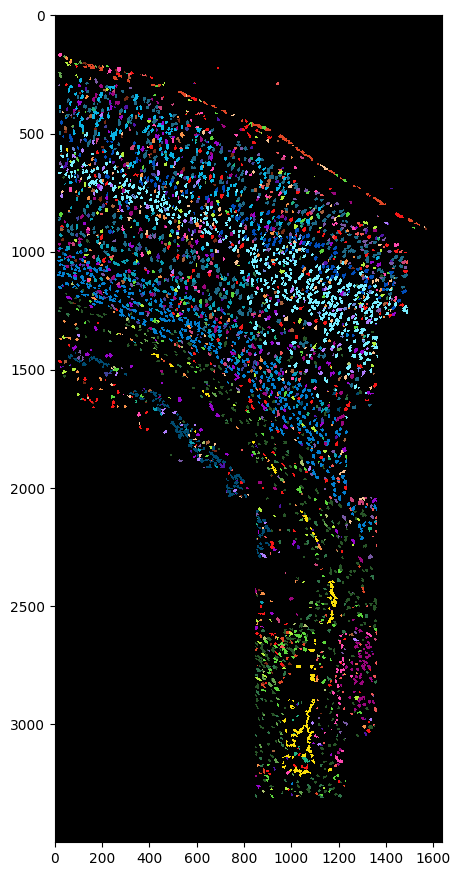

In [56]:
# import linear color maps:
from matplotlib.colors import LinearSegmentedColormap

osmfish_cmap = LinearSegmentedColormap.from_list("osmfish", list(osmfish_ref_colors.values()), N=len(osmfish_colors))
osmfish_cmap.set_bad((0, 0, 0, 0))
osmfish_cmap.set_under((0, 0, 0, 0))
osmfish_cmap.set_over((0, 0, 0, 0))

plt.figure(figsize=(5,15))
plt.subplot(111,facecolor='black')
plt.imshow(cell_matrix_raw.argmax(0).T[:,::-1], cmap=osmfish_cmap,interpolation='none',alpha=(cell_matrix_raw.sum(0)>0).astype(float).T[:,::-1])

In [117]:
from sonar import sonar,utils

son = sonar.Sonar(max_radius=1000,linear_radius_steps=20,circumference_normalization=True,edge_correction=False,labels=celltype_names_raw)
cooc_template_ = son.co_occurrence_from_tensor(cell_matrix_raw,interpolate='linear',area_normalization=False,memory_efficient=True)


: 

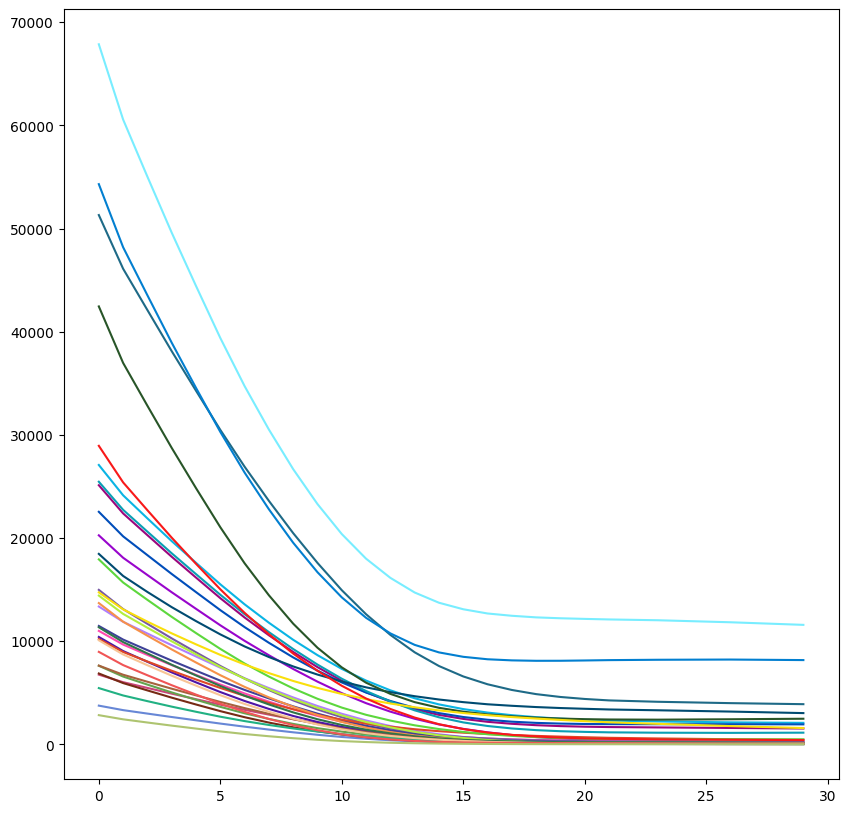

In [120]:
plt.figure(figsize=(10,10))

oligo_mask = np.array([name.startswith('Oligo') for name in osmfish_ref_colors]) 

for i,(cluster,color) in enumerate(osmfish_ref_colors.items()):
    
    plt.plot(cooc_template_[i,i,:30],color=color)
    
# cooc_template_[i,oligo_mask,:].sum(1)

# [name for name in osmfish_ref_colors]

In [121]:
from sonar import sonar
from time import perf_counter

# son = sonar.Sonar(max_radius=100,linear_steps=5)

# pc = perf_counter()
# co_occurrences = son.co_occurrence_from_tensor(cell_matrix_raw)
# print(perf_counter() - pc)

In [122]:
def normalize_co_occurrence(tensor, sonar_obj, original_img): # when sonar will be fixed, the function will need only sonar obj
    """
    Normalize co-occurrence results based on cell type proportions.

    Args:
        tensor (numpy.ndarray): Co-occurrence tensor to normalize.
        sonar_obj (SonarObject): The SonarObject containing metadata.
        original_img (numpy.ndarray): Original image data.

    Returns:
        normalized_coocur (numpy.ndarray): Normalized co-occurrence tensor.
    """
    
    # Normalisation
    n, _, m = tensor.shape
    normalized_coocur = np.zeros_like(tensor)
    
    for i in range(n):
        for j in range(n):
            for k in range(m):
                normalized_coocur[i, j, k] = tensor[i, j, k] / (son.meta['pixel_counts'].values[j]*son.meta['pixel_proportions'].values[i])

    return normalized_coocur

normalized_coocur = normalize_co_occurrence(tensor=cooc_template_, sonar_obj=son, original_img = None)

In [123]:
from scipy import stats
import statsmodels.stats.multitest as smm


def significance_test(normalized_coocur=normalized_coocur, log10p_corrected = True):
    """
    Perform significance tests on normalized co-occurrence data.

    This function conducts significance tests to determine if the normalized co-occurrence values
    are significantly different from the overall mean. It uses t-tests for each cell type pair and distance.

    Args:
        normalized_coocur (numpy.ndarray): 3D array of normalized co-occurrence values.
        metadata: Additional metadata (not used in this function).

    Returns:
        less_greater (tuple of numpy.ndarray): tuple of two elements that contains arrays of corrected p-values which show 
        the significance of correlation values for "less" and "greater" alternatives.

    Note:
        The p-values are corrected for multiple hypothesis testing using the Benjamini-Hochberg procedure (method='fdr_bh').
        This correction helps control the False Discovery Rate (FDR) when conducting numerous tests.
        Corrected p-values are provided in the returned 3D arrays for further interpretation and analysis.
    """
    less_greater = [] # maybe should be changed to numpy.ndarray, but I find a list more convenient in this case

    # performing 1-sided ttest with two alternative options: lees and greater, to see both "ups" and "donws"
    alternatives = ["less", "greater"]
    for one_side in alternatives:

        significance_test = np.zeros((normalized_coocur.shape[0],normalized_coocur.shape[1],normalized_coocur.shape[2]))
        for pivot_cell_type in range(normalized_coocur.shape[0]):
            for target_cell_type in range(normalized_coocur.shape[1]):
                for distance in range(normalized_coocur.shape[2]):

                    value_to_test = normalized_coocur[pivot_cell_type, target_cell_type, distance]
                    t_statistic, p_value = stats.ttest_1samp(normalized_coocur[pivot_cell_type,:,distance], value_to_test, alternative=one_side)
                    significance_test[pivot_cell_type, target_cell_type, distance] = p_value

    # correction for multiple hypothesis testing
        significance_test_flatten = significance_test.flatten()
        corrected_p_values = smm.multipletests(significance_test_flatten, method='fdr_bh')[1] 
        corrected_p_values3D = corrected_p_values.reshape(normalized_coocur.shape[0],normalized_coocur.shape[1],normalized_coocur.shape[2])

        if log10p_corrected:
            corrected_p_values3D = -np.log10(corrected_p_values3D)
        
        less_greater.append(corrected_p_values3D)

    return less_greater[0], less_greater[1]


significant_enri, significant_depl  = significance_test(normalized_coocur=normalized_coocur)

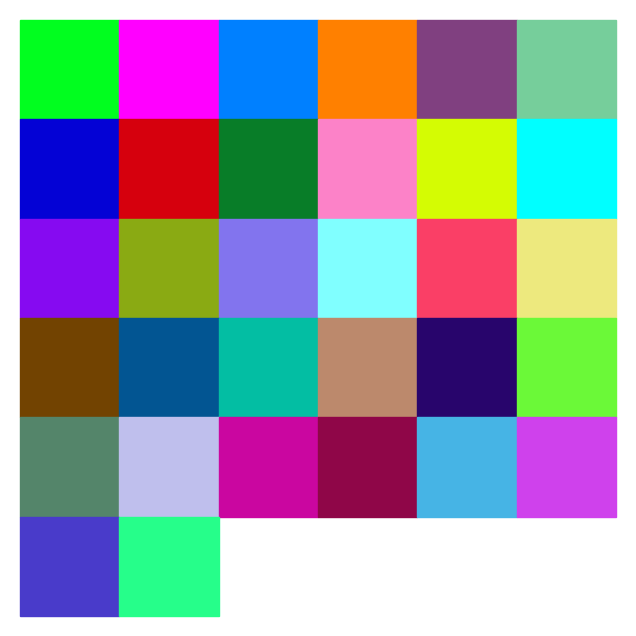

In [124]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

from distinctipy import distinctipy
import random
random.seed(13)

# number of colours to generate
# N = len(indices_above_threshold)
N = 32

# generate N visually distinct colours
curves_colors = distinctipy.get_colors(N)

# display the colours
distinctipy.color_swatch(curves_colors)

enr_val_modif = significant_enri.copy()
enr_val_modif[enr_val_modif<2] = 0


# Create your custom colormap
colors = [(0.4, 0.7, 0.9), (0, 0, 0), (1, 0, 0)]  # Blue, Black, Red
n_bins = 1200  # Number of bins in the colormap
cmap_name = 'custom_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

custom_cmap_np = custom_cmap(np.linspace(0, 1, 1200))
black = np.array([0, 0, 0, 1])
custom_cmap_np[400:800, :] = black
custom_cmap_2black = ListedColormap(custom_cmap_np)



depl_val_modif = significant_depl.copy()
depl_val_modif[depl_val_modif<2] = 0

enr_depl_merged = enr_val_modif + depl_val_modif
enr_depl_merged = significant_enri-significant_depl

depl_color = [ (0, 0, 0),(0.4, 0.7, 0.9)]
n_bins = 600  # Number of bins in the colormap
depl_cmap_name = 'depl_cmap'
depl_cmap = LinearSegmentedColormap.from_list(depl_cmap_name, depl_color, N=n_bins)

depl_cmap_np = depl_cmap(np.linspace(0, 1, 600))
black = np.array([0, 0, 0, 1])
depl_cmap_np[:200, :] = black
depl_cmap_2black = ListedColormap(depl_cmap_np)
 

enr_color = [(0, 0, 0), (1, 0, 0)]
n_bins = 600  # Number of bins in the colormap
enr_cmap_name = 'depl_cmap'
enr_cmap = LinearSegmentedColormap.from_list(enr_cmap_name, enr_color, N=n_bins)

enr_cmap_np = enr_cmap(np.linspace(0, 1, 600))
black = np.array([0, 0, 0, 1])
enr_cmap_np[:200, :] = black
enr_cmap_2black = ListedColormap(enr_cmap_np)

In [125]:
son

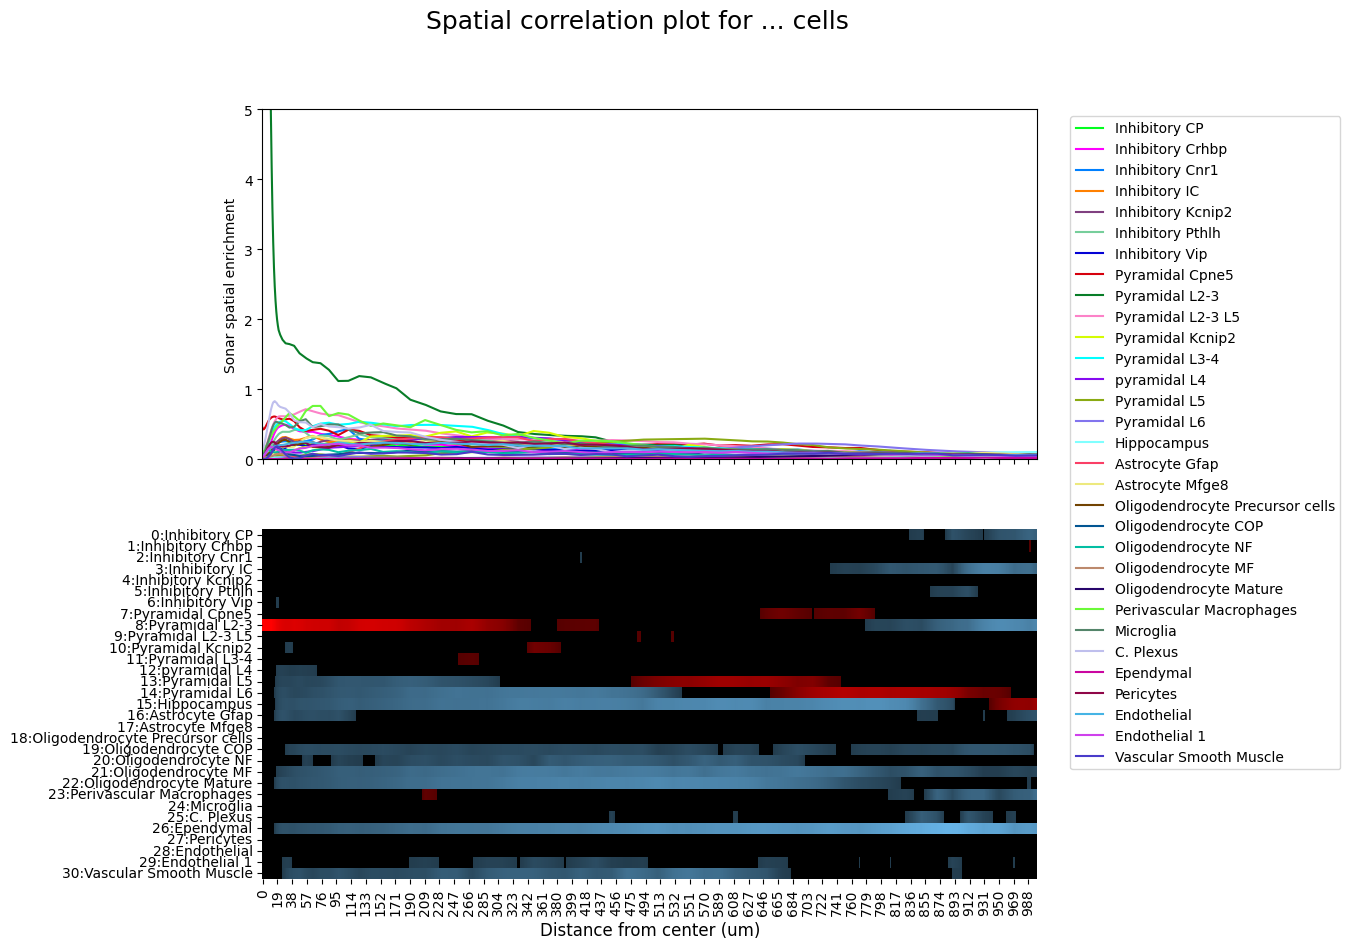

In [131]:
import seaborn as sns

ct_of_interest = 8

# hidden heatmaps for colorbars
fig_not_show, (ax_noshow_enri, ax_noshow_depl) = plt.subplots(ncols=2, figsize = (10,5))
sns.heatmap(enr_val_modif[ct_of_interest,:,:], cmap=enr_cmap_2black, ax=ax_noshow_enri, cbar=False, xticklabels=False, yticklabels=False, vmin = 0, vmax=6)
sns.heatmap(-depl_val_modif[ct_of_interest,:,:], cmap=depl_cmap_2black, ax=ax_noshow_depl, cbar=False, xticklabels=False, yticklabels=False, vmin = 0, vmax=6)
plt.close()


fig, (ax_curve, ax_show_comb) = plt.subplots(2,1, figsize = (10,10), sharex=True)
plt.suptitle("Spatial correlation plot for ... cells", fontsize = 18)

for target_cell_type in range(normalized_coocur.shape[0]):
    # ax_curve = axes[0]
    ax_curve.plot(normalized_coocur[ct_of_interest,target_cell_type], color=curves_colors[target_cell_type % len(curves_colors)], label=(son.meta.index.to_list()[target_cell_type]))
    ax_curve.legend(loc="upper right", bbox_to_anchor=(1.4, 1))
    ax_curve.set_ylim(0,5)
ax_curve.set_ylabel("Sonar spatial enrichment")


#, width_ratios=[0.99999,0.0000005,0.0000005])
# fig.subplots_adjust(wspace=0.01)
sns.heatmap(enr_depl_merged[ct_of_interest,:,:], cmap=custom_cmap_2black, ax=ax_show_comb, cbar=False, yticklabels = [f"{i}:{name}" for i,name in enumerate(son.meta.index)])
ax_show_comb.set_xlabel('Distance from center (um)', fontsize = 12)
# ax_show_comb.text(590,1,"Significance \n (-log10 p-value)", fontsize=12, ha="right", va='top')

# cbar_ax1 = fig.add_axes([0.93, 0.12, 0.02, 0.25]) #parameters for colorbars (left, bottom, width, hight)
# cbar_ax1.text(-1.1,3.5,"Enrichment", fontsize = 10, rotation=90) #needed to be transfer to proportions
# cbar_ax2 = fig.add_axes([0.999, 0.12, 0.02, 0.25]) 
# cbar_ax2.text(-1.1,3.8,"Depletion", fontsize = 10, rotation=90) #needed to be transfer to proportions
# cbar_ax.axis("off")

cbar_enr = fig.colorbar(ax_noshow_enri.collections[0], cax=cbar_ax1, location="right", use_gridspec=False, shrink=5, pad = 0.5)
cbar_depl = fig.colorbar(ax_noshow_depl.collections[0], cax=cbar_ax2, location="right", use_gridspec=False, shrink=5)

cbar_adapted_ticks = [0,0,2,0,4,0,6]
cbar_enr.set_ticks(cbar_adapted_ticks)
cbar_depl.set_ticks(cbar_adapted_ticks)